# GVH Diagonal Cubic 0.2.19 — Linearized Field Equations and Wave Polarizations
## Équations linéarisées, propagation, polarisations et réponse d’un détecteur

**Auteur : Charlemagne O Laurince**

## Objectif

Étudier autour de Minkowski :

\[
g_{\mu\nu}=\eta_{\mu\nu}+h_{\mu\nu},
\qquad
\bar D_{\mu\nu}=\delta\bar D_{\mu\nu},
\]

avec deux modes métriques \(h_+,h_\times\) et cinq modes directionnels \(q_A\).

Le notebook dérive les équations linéarisées, les dispersions, une base de cinq polarisations sans trace, la déformation de particules tests, une réponse instrumentale géométrique, la propagation dispersive et un mélange métrique–directionnel.

La réponse réelle d’un détecteur reste conditionnée par un couplage matière–GVH encore non dérivé.


In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)
print("Environnement chargé.")


Environnement chargé.


# 1. Équations linéarisées

Dans la jauge transverse et sans trace :

\[
\ddot h_\lambda-\nabla^2 h_\lambda=0,
\qquad
\lambda\in\{+,\times\}.
\]

Les cinq modes directionnels satisfont :

\[
K_D\ddot q_A-G_D\nabla^2q_A+m_D^2q_A=0.
\]


In [2]:
t,x,y,z = sp.symbols("t x y z", real=True)
K_D,G_D,m_D2 = sp.symbols("K_D G_D m_D2", positive=True, real=True)

h_plus = sp.Function("h_plus")(t,x,y,z)
h_cross = sp.Function("h_cross")(t,x,y,z)
q_fields = [sp.Function(f"q{i}")(t,x,y,z) for i in range(1,6)]

def wave_op(f):
    return sp.simplify(
        sp.diff(f,t,2)-sp.diff(f,x,2)-sp.diff(f,y,2)-sp.diff(f,z,2)
    )

metric_eqs = [wave_op(h_plus), wave_op(h_cross)]
directional_eqs = [
    sp.simplify(
        K_D*sp.diff(q,t,2)
        - G_D*(sp.diff(q,x,2)+sp.diff(q,y,2)+sp.diff(q,z,2))
        + m_D2*q
    )
    for q in q_fields
]

display(metric_eqs[0])
display(directional_eqs[0])


 2                        2                        2                        2  ↪
∂                        ∂                        ∂                        ∂   ↪
───(hₚₗᵤₛ(t, x, y, z)) - ───(hₚₗᵤₛ(t, x, y, z)) - ───(hₚₗᵤₛ(t, x, y, z)) - ─── ↪
  2                        2                        2                        2 ↪
∂t                       ∂x                       ∂y                       ∂z  ↪

↪                    
↪                    
↪ (hₚₗᵤₛ(t, x, y, z))
↪                    
↪                    

      ⎛ 2                     2                     2                 ⎞        ↪
      ⎜∂                     ∂                     ∂                  ⎟        ↪
- G_D⋅⎜───(q₁(t, x, y, z)) + ───(q₁(t, x, y, z)) + ───(q₁(t, x, y, z))⎟ + K_D⋅ ↪
      ⎜  2                     2                     2                ⎟        ↪
      ⎝∂x                    ∂y                    ∂z                 ⎠        ↪

↪  2                                       
↪ ∂                                        
↪ ───(q₁(t, x, y, z)) + m_D2⋅q₁(t, x, y, z)
↪   2                                      
↪ ∂t                                       

# 2. Ondes planes et dispersion

Pour :

\[
e^{i(kz-\omega t)},
\]

on obtient :

\[
\omega_h^2=k^2,
\]

et :

\[
\omega_D^2=\frac{G_D}{K_D}k^2+\frac{m_D^2}{K_D}.
\]


In [3]:
omega,k = sp.symbols("omega k", real=True)
plane = sp.exp(sp.I*(k*z-omega*t))

metric_residual = sp.simplify(wave_op(plane)/plane)
directional_residual = sp.simplify(
    (
        K_D*sp.diff(plane,t,2)
        - G_D*sp.diff(plane,z,2)
        + m_D2*plane
    )/plane
)

display(metric_residual)
display(directional_residual)

cD2 = sp.simplify(G_D/K_D)
meff2 = sp.simplify(m_D2/K_D)
omegaD = sp.sqrt(cD2*k**2+meff2)
vphase = sp.simplify(omegaD/k)
vgroup = sp.simplify(sp.diff(omegaD,k))

display(vphase)
display(vgroup)


 2    2
k  - ω 

     2        2       
G_D⋅k  - K_D⋅ω  + m_D2

   _______________
  ╱      2        
╲╱  G_D⋅k  + m_D2 
──────────────────
      _____       
    ╲╱ K_D ⋅k     

          G_D⋅k           
──────────────────────────
           _______________
  _____   ╱      2        
╲╱ K_D ⋅╲╱  G_D⋅k  + m_D2 

# 3. Base de cinq polarisations sans trace

Nous choisissons une base orthonormale de l’espace des matrices symétriques sans trace \(3\times3\).


In [4]:
s2 = sp.sqrt(2)
s6 = sp.sqrt(6)

E1 = sp.Matrix([[1,0,0],[0,-1,0],[0,0,0]])/s2
E2 = sp.Matrix([[1,0,0],[0,1,0],[0,0,-2]])/s6
E3 = sp.Matrix([[0,1,0],[1,0,0],[0,0,0]])/s2
E4 = sp.Matrix([[0,0,1],[0,0,0],[1,0,0]])/s2
E5 = sp.Matrix([[0,0,0],[0,0,1],[0,1,0]])/s2

basis = [E1,E2,E3,E4,E5]

gram = sp.Matrix([
    [sp.simplify(sp.trace(A.T*B)) for B in basis]
    for A in basis
])

traces = [sp.simplify(sp.trace(E)) for E in basis]

display(gram)
display(sp.Matrix(traces))


⎡1  0  0  0  0⎤
⎢             ⎥
⎢0  1  0  0  0⎥
⎢             ⎥
⎢0  0  1  0  0⎥
⎢             ⎥
⎢0  0  0  1  0⎥
⎢             ⎥
⎣0  0  0  0  1⎦

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

# 4. Interprétation géométrique provisoire

- \(E_1\) : forme transverse de type \(+\) ;
- \(E_3\) : forme transverse de type \(\times\) ;
- \(E_2\) : déformation diagonale avec composante longitudinale ;
- \(E_4\) : cisaillement \(xz\) ;
- \(E_5\) : cisaillement \(yz\).

La similarité géométrique ne signifie pas identité physique avec les deux polarisations métriques de la relativité générale.


In [5]:
polarization_table = pd.DataFrame([
    {"mode":"E1","geometry":"plus-like transverse","status":"directional analogue"},
    {"mode":"E2","geometry":"diagonal trace-free, longitudinal content","status":"extra candidate"},
    {"mode":"E3","geometry":"cross-like transverse","status":"directional analogue"},
    {"mode":"E4","geometry":"xz shear","status":"extra candidate"},
    {"mode":"E5","geometry":"yz shear","status":"extra candidate"}
])
polarization_table


,mode,geometry,status
0,E1,plus-like transverse,directional analogue
1,E2,"diagonal trace-free, longitudinal content",extra candidate
2,E3,cross-like transverse,directional analogue
3,E4,xz shear,extra candidate
4,E5,yz shear,extra candidate


# 5. Déformation de particules tests

Une perturbation spatiale \(P\) transforme schématiquement :

\[
\delta\mathbf X=\frac{A}{2}P\mathbf X.
\]


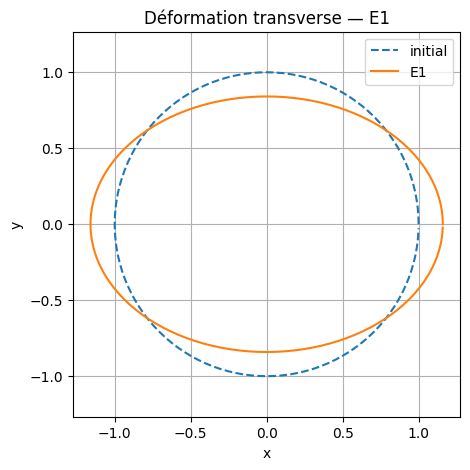

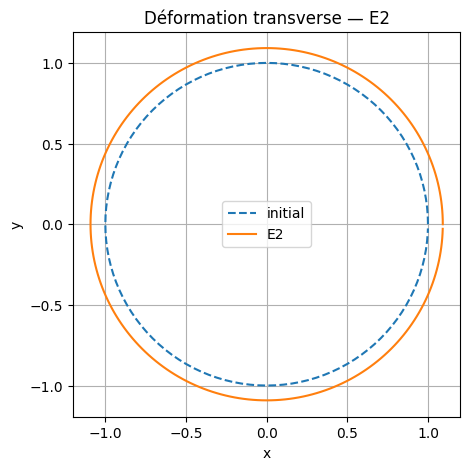

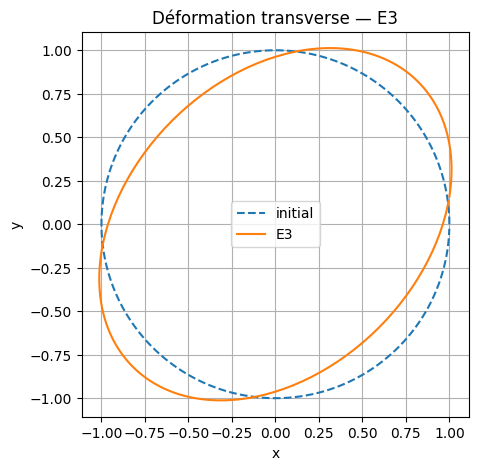

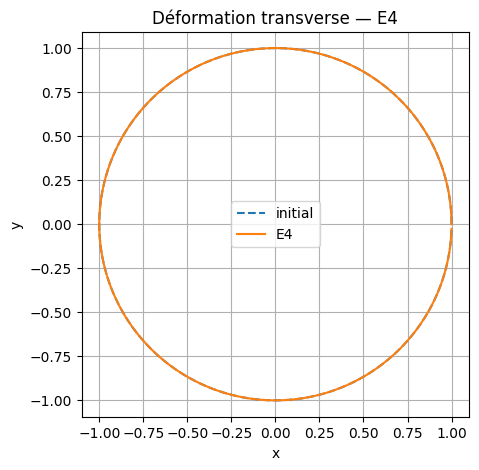

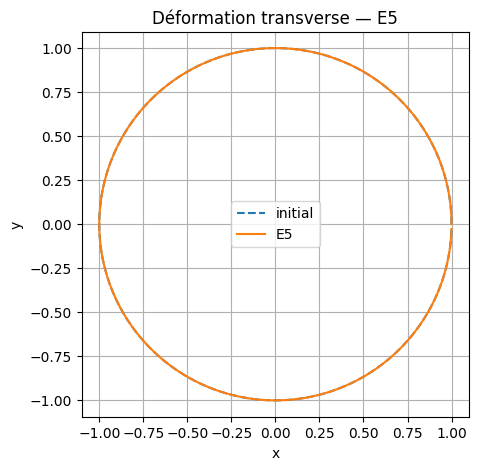

In [6]:
angles = np.linspace(0,2*np.pi,240,endpoint=False)
ring = np.vstack([np.cos(angles),np.sin(angles),np.zeros_like(angles)])

def deform(points,P,amplitude=0.45):
    P = np.array(P,dtype=float)
    return (np.eye(3)+0.5*amplitude*P)@points

for i,E in enumerate(basis,1):
    d = deform(ring,E)
    plt.figure(figsize=(5,5))
    plt.plot(ring[0],ring[1],linestyle="--",label="initial")
    plt.plot(d[0],d[1],label=f"E{i}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Déformation transverse — E{i}")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()


# 6. Réponse géométrique d’un interféromètre

Pour deux bras unitaires \(\mathbf u,\mathbf v\) :

\[
D^{ij}=\frac12(u^iu^j-v^iv^j),
\]

et :

\[
F_P=D^{ij}P_{ij}.
\]


In [7]:
u = np.array([1.0,0.0,0.0])
v = np.array([0.0,1.0,0.0])
Ddet = 0.5*(np.outer(u,u)-np.outer(v,v))

def response(D,P):
    return float(np.sum(D*np.array(P,dtype=float)))

response_df = pd.DataFrame([
    {"polarization":f"E{i+1}","response":response(Ddet,E)}
    for i,E in enumerate(basis)
])
response_df


,polarization,response
0,E1,0.707107
1,E2,0.000000
2,E3,0.000000
3,E4,0.000000
4,E5,0.000000


# 7. Réponse angulaire du détecteur


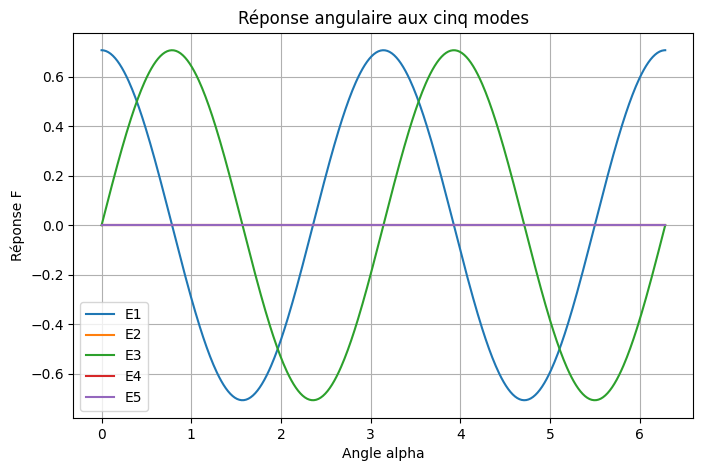

In [8]:
alphas = np.linspace(0,2*np.pi,500)
curves = {f"E{i+1}":[] for i in range(5)}

for a in alphas:
    u = np.array([np.cos(a),np.sin(a),0.0])
    v = np.array([-np.sin(a),np.cos(a),0.0])
    D = 0.5*(np.outer(u,u)-np.outer(v,v))
    for i,E in enumerate(basis):
        curves[f"E{i+1}"].append(response(D,E))

plt.figure(figsize=(8,5))
for name,vals in curves.items():
    plt.plot(alphas,vals,label=name)
plt.xlabel("Angle alpha")
plt.ylabel("Réponse F")
plt.title("Réponse angulaire aux cinq modes")
plt.grid(True)
plt.legend()
plt.show()


# 8. Propagation et retard

Pour un mode directionnel :

\[
v_g=
\frac{c_D^2k}{\sqrt{c_D^2k^2+m_{\rm eff}^2}},
\]

et un retard relatif à un signal luminal :

\[
\Delta t=L\left(\frac1{v_g}-1\right).
\]


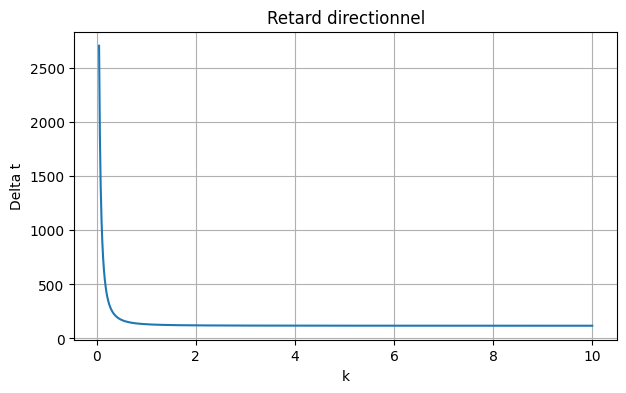

In [9]:
def vg(kv,KD=1.0,GD=0.8,M2=0.02):
    om2 = GD/KD*kv**2 + M2/KD
    return (GD/KD)*kv/np.sqrt(om2)

kvals = np.linspace(0.05,10,600)
vgvals = vg(kvals)
delay = 1000*(1/vgvals-1)

plt.figure(figsize=(7,4))
plt.plot(kvals,delay)
plt.xlabel("k")
plt.ylabel("Delta t")
plt.title("Retard directionnel")
plt.grid(True)
plt.show()


# 9. Paquet d’onde dispersif


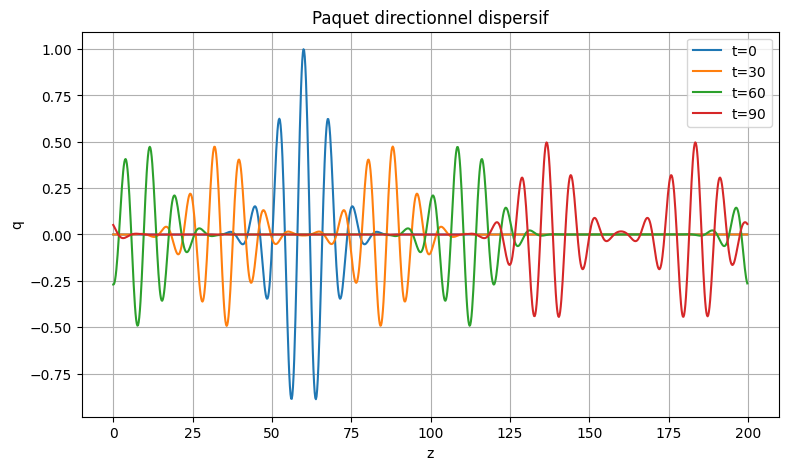

In [10]:
Nz = 1024
Lz = 200.0
dz = Lz/Nz
zg = np.arange(Nz)*dz

z0,sigma,k0 = 60.0,8.0,0.8
packet0 = np.exp(-(zg-z0)**2/(2*sigma**2))*np.cos(k0*(zg-z0))

kfft = 2*np.pi*np.fft.fftfreq(Nz,d=dz)
packet_fft = np.fft.fft(packet0)

def evolve_packet(T,c2=0.8,M2=0.05):
    om = np.sqrt(c2*kfft**2+M2)
    return np.real(np.fft.ifft(packet_fft*np.exp(-1j*om*T)))

plt.figure(figsize=(9,5))
for T in [0,30,60,90]:
    plt.plot(zg,evolve_packet(T),label=f"t={T}")
plt.xlabel("z")
plt.ylabel("q")
plt.title("Paquet directionnel dispersif")
plt.grid(True)
plt.legend()
plt.show()


# 10. Mélange métrique–directionnel

Un modèle à deux modes est :

\[
\ddot{\mathbf X}+\mathbf\Omega^2\mathbf X=0,
\qquad
\mathbf X=(h_+,q_1)^\mathsf T.
\]


In [11]:
mu2 = sp.symbols("mu2", real=True)
Omega2 = sp.Matrix([
    [k**2,mu2],
    [mu2,cD2*k**2+meff2]
])

display(Omega2)
for eig in Omega2.eigenvals():
    display(sp.simplify(eig))


⎡ 2               ⎤
⎢k        μ₂      ⎥
⎢                 ⎥
⎢         2       ⎥
⎢    G_D⋅k    m_D2⎥
⎢μ₂  ────── + ────⎥
⎣     K_D     K_D ⎦

                            __________________________________________________ ↪
     2        2            ╱    2  4              4          2           2  4  ↪
G_D⋅k  + K_D⋅k  + m_D2 - ╲╱  G_D ⋅k  - 2⋅G_D⋅K_D⋅k  + 2⋅G_D⋅k ⋅m_D2 + K_D ⋅k   ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                       2⋅K_D                   ↪

↪ _____________________________________
↪        2   2          2            2 
↪ + 4⋅K_D ⋅μ₂  - 2⋅K_D⋅k ⋅m_D2 + m_D2  
↪ ─────────────────────────────────────
↪                                      

                            __________________________________________________ ↪
     2        2            ╱    2  4              4          2           2  4  ↪
G_D⋅k  + K_D⋅k  + m_D2 + ╲╱  G_D ⋅k  - 2⋅G_D⋅K_D⋅k  + 2⋅G_D⋅k ⋅m_D2 + K_D ⋅k   ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                       2⋅K_D                   ↪

↪ _____________________________________
↪        2   2          2            2 
↪ + 4⋅K_D ⋅μ₂  - 2⋅K_D⋅k ⋅m_D2 + m_D2  
↪ ─────────────────────────────────────
↪                                      

# 11. Conversion entre modes


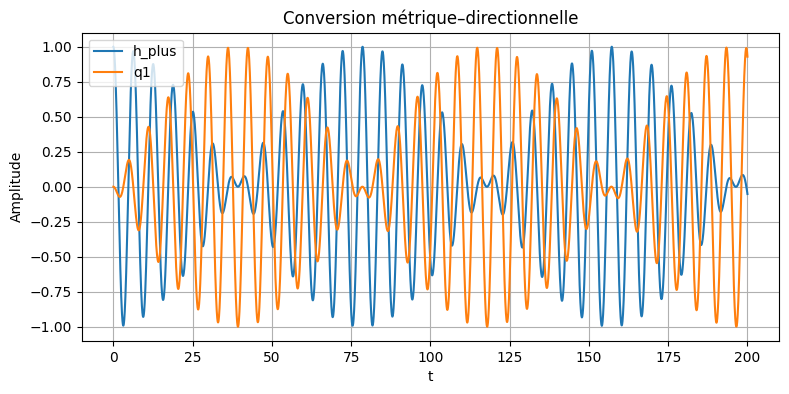

In [12]:
def integrate_mix(kval=1.0,c2=0.8,M2=0.2,coupling=0.08,tmax=200):
    Om2 = np.array([[kval**2,coupling],[coupling,c2*kval**2+M2]])
    def rhs(T,state):
        X = state[:2]
        V = state[2:]
        return np.concatenate([V,-Om2@X])
    times = np.linspace(0,tmax,5000)
    sol = solve_ivp(
        rhs,(0,tmax),[1,0,0,0],t_eval=times,
        method="DOP853",rtol=1e-10,atol=1e-12
    )
    return sol,Om2

sol,Om2_num = integrate_mix()

plt.figure(figsize=(9,4))
plt.plot(sol.t,sol.y[0],label="h_plus")
plt.plot(sol.t,sol.y[1],label="q1")
plt.xlabel("t")
plt.ylabel("Amplitude")
plt.title("Conversion métrique–directionnelle")
plt.grid(True)
plt.legend()
plt.show()


# 12. Conservation de l’énergie du système mixte


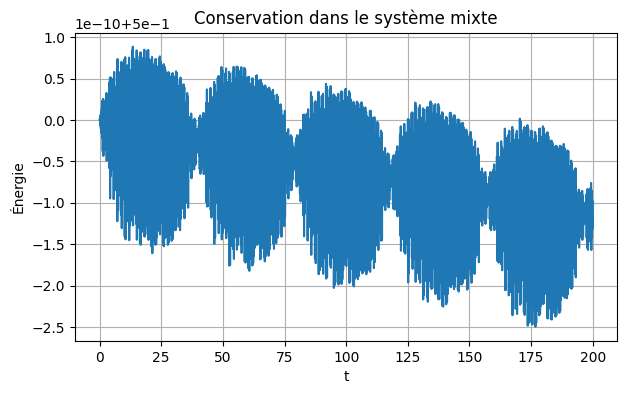

Dérive relative : 6.758797966559331e-10


In [13]:
X = sol.y[:2]
V = sol.y[2:]
energy = np.array([
    0.5*V[:,i]@V[:,i] + 0.5*X[:,i]@Om2_num@X[:,i]
    for i in range(X.shape[1])
])

energy_drift = (energy.max()-energy.min())/abs(energy.mean())

plt.figure(figsize=(7,4))
plt.plot(sol.t,energy)
plt.xlabel("t")
plt.ylabel("Énergie")
plt.title("Conservation dans le système mixte")
plt.grid(True)
plt.show()

print("Dérive relative :",energy_drift)


# 13. Signatures observationnelles candidates

Les signatures possibles sont :

- modes supplémentaires ;
- dispersion fréquentielle ;
- retard d’arrivée ;
- composantes longitudinales ou de cisaillement ;
- battements ;
- conversion métrique–directionnelle.

Elles ne deviennent des prédictions qu’après dérivation des couplages à la matière et aux détecteurs.


In [14]:
signatures = pd.DataFrame([
    {"signature":"extra polarizations","status":"coupling not derived"},
    {"signature":"frequency dispersion","status":"candidate if m_D2 > 0"},
    {"signature":"arrival-time delay","status":"candidate if v_g < 1"},
    {"signature":"mode conversion","status":"exploratory mixing"},
    {"signature":"beating","status":"candidate under simultaneous excitation"}
])
signatures


,signature,status
0,extra polarizations,coupling not derived
1,frequency dispersion,candidate if m_D2 > 0
2,arrival-time delay,candidate if v_g < 1
3,mode conversion,exploratory mixing
4,beating,candidate under simultaneous excitation


# 14. Limite d’Einstein

Lorsque :

\[
q_A=0,
\qquad
\mu_{hD}=0,
\]

il reste :

\[
h_+,\qquad h_\times,
\]

avec :

\[
\omega^2=k^2,\qquad v_g=1.
\]


In [15]:
einstein_limit = pd.DataFrame([
    {"mode":"h_plus","mass":0,"speed":1},
    {"mode":"h_cross","mass":0,"speed":1}
])
einstein_limit


,mode,mass,speed
0,h_plus,0,1
1,h_cross,0,1


# 15. Paramètres encore nécessaires

\[
K_D,\quad G_D,\quad m_D^2
\]

définissent la propagation libre.

Il reste à dériver :

\[
g_A^{\rm matter},\quad
g_A^{\rm detector},\quad
\mu_{hD}.
\]


In [16]:
parameter_table = pd.DataFrame([
    {"parameter":"K_D","role":"kinetic normalization","status":"defined"},
    {"parameter":"G_D","role":"propagation speed","status":"defined"},
    {"parameter":"m_D2","role":"effective mass","status":"defined"},
    {"parameter":"g_A_matter","role":"coupling to matter","status":"not derived"},
    {"parameter":"g_A_detector","role":"detector response","status":"not derived"},
    {"parameter":"mu_hD","role":"mode conversion","status":"exploratory"}
])
parameter_table


,parameter,role,status
0,K_D,kinetic normalization,defined
1,G_D,propagation speed,defined
2,m_D2,effective mass,defined
3,g_A_matter,coupling to matter,not derived
4,g_A_detector,detector response,not derived
5,mu_hD,mode conversion,exploratory


# 16. Validation automatique


In [17]:
metric_dispersion_ok = sp.simplify(metric_residual + omega**2-k**2) == 0
directional_dispersion_ok = sp.simplify(
    directional_residual + K_D*omega**2-G_D*k**2-m_D2
) == 0
gram_ok = gram == sp.eye(5)
trace_ok = all(sp.simplify(sp.trace(E))==0 for E in basis)
energy_ok = energy_drift < 1e-8
einstein_ok = (
    len(einstein_limit)==2
    and (einstein_limit["mass"]==0).all()
    and (einstein_limit["speed"]==1).all()
)

validation_df = pd.DataFrame([
    {"test":"metric dispersion","status":"PASS" if metric_dispersion_ok else "FAIL"},
    {"test":"directional dispersion","status":"PASS" if directional_dispersion_ok else "FAIL"},
    {"test":"polarization orthonormality","status":"PASS" if gram_ok else "FAIL"},
    {"test":"polarization tracelessness","status":"PASS" if trace_ok else "FAIL"},
    {"test":"mixed energy conservation","status":"PASS" if energy_ok else "CHECK"},
    {"test":"Einstein wave limit","status":"PASS" if einstein_ok else "FAIL"}
])
validation_df


,test,status
0,metric dispersion,PASS
1,directional dispersion,PASS
2,polarization orthonormality,PASS
3,polarization tracelessness,PASS
4,mixed energy conservation,PASS
5,Einstein wave limit,PASS


In [18]:
overall_status = (
    "PASS-MINIMAL-WAVES"
    if (validation_df["status"]=="PASS").all()
    else "CHECK"
)
print("STATUT :",overall_status)
print("Couplage aux détecteurs : non encore dérivé.")


STATUT : PASS-MINIMAL-WAVES
Couplage aux détecteurs : non encore dérivé.


# 17. Export


In [19]:
import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.19_Validation.csv",index=False
)
polarization_table.to_csv(
    "GVH_Diagonal_Cubic_0.2.19_Polarizations.csv",index=False
)
response_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.19_Detector_Response.csv",index=False
)
signatures.to_csv(
    "GVH_Diagonal_Cubic_0.2.19_Candidate_Signatures.csv",index=False
)
parameter_table.to_csv(
    "GVH_Diagonal_Cubic_0.2.19_Parameters.csv",index=False
)

metadata = {
    "status":overall_status,
    "metric_modes":2,
    "directional_modes":5,
    "metric_dispersion":"omega^2 = k^2",
    "directional_dispersion":"omega^2 = (G_D/K_D)k^2 + m_D^2/K_D",
    "detector_response":"geometric prototype only",
    "matter_coupling":"not derived",
    "Einstein_limit":"two massless luminal modes"
}

with open(
    "GVH_Diagonal_Cubic_0.2.19_Metadata.json","w",encoding="utf-8"
) as f:
    json.dump(metadata,f,indent=2,ensure_ascii=False)

print("Exports terminés.")


Exports terminés.


# 18. Conclusion

Le modèle minimal donne :

\[
\boxed{
\ddot h_\lambda-\nabla^2h_\lambda=0
}
\]

et :

\[
\boxed{
\ddot q_A-\frac{G_D}{K_D}\nabla^2q_A+\frac{m_D^2}{K_D}q_A=0
}.
\]

Le spectre contient :

\[
\boxed{
2\text{ modes métriques}
+
5\text{ modes directionnels}
}.
\]

Les cinq matrices directionnelles forment une base orthonormale des déformations spatiales symétriques sans trace.

La limite de la relativité générale est obtenue avec :

\[
q_A=0,\qquad \mu_{hD}=0.
\]

La prochaine étape est :

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.20\_Matter\_Coupling\_Detector\_Response.ipynb}
}
\]
